# P1c · Padrón Change vs Estimated Migratory Balance (1998–2024)
## *Comparison of p1a and p1b Series by Municipality Size and Goerlich (2016) Typology*

---

**Paper:** Rural Migration and Land Use in Spain — Paper 1  
**Step:** 1c — Comparative analysis (Part C of three)  
**Author:** Juan Zotes  
**Last updated:** 2026-03-25

---

### Context and purpose

This notebook produces comparative figures overlaying the two series computed in p1a and p1b:

- **p1a** — Annual net padrón change: integrates migratory and vegetative components
- **p1b** — Estimated migratory balance: migratory component only, vegetative balance removed

The gap between the two lines is the **vegetative balance**, which is structurally
negative in small rural municipalities. The shaded area between the lines makes
this gap visible and interpretable.

This is **Part C** of a three-notebook series:

| Notebook | Outcome variable | Source |
|----------|-----------------|--------|
| p1a | Net padrón change (ΔP) | Padrón Municipal 1996–2024 |
| p1b | Estimated migratory balance (ΔP − V) | Padrón + MNP 1998–2024 |
| **p1c** (this notebook) | Comparison of p1a and p1b | — |

### Inputs

| File | Location | Description |
|------|----------|-------------|
| `p1_annual_net_change_national.csv` | `data/demography/derived/` | p1a national series |
| `p1_annual_net_change_by_size.csv` | `data/demography/derived/` | p1a by size group |
| `p1_annual_net_change_by_typology.csv` | `data/demography/derived/` | p1a by typology |
| `p1b_annual_mig_balance_national.csv` | `data/demography/derived/` | p1b national series |
| `p1b_annual_mig_balance_by_size.csv` | `data/demography/derived/` | p1b by size group |
| `p1b_annual_mig_balance_by_typology.csv` | `data/demography/derived/` | p1b by typology |

In [1]:
"""
Notebook  : p1c_comparison_padron_vs_migratory.ipynb
Author    : Juan Zotes
Created   : 2026-03-25

Purpose:
    Compare net padron change (p1a) with estimated migratory balance (p1b)
    using overlaid line charts with shaded vegetative balance gap.

Inputs:
    - p1_annual_net_change_national.csv          (demography/derived)
    - p1_annual_net_change_by_size.csv           (demography/derived)
    - p1_annual_net_change_by_typology.csv       (demography/derived)
    - p1b_annual_mig_balance_national.csv        (demography/derived)
    - p1b_annual_mig_balance_by_size.csv         (demography/derived)
    - p1b_annual_mig_balance_by_typology.csv     (demography/derived)

Outputs:
    Figures (figures/p1c_comparison/):
        - p1c_fig1_national_{lang}.png
        - p1c_fig2_size_combined_{lang}.png
        - p1c_fig2_size_pair_{top/mid/bot}_{lang}.png
        - p1c_fig2_size_individual_{group}_{lang}.png
        - p1c_fig3_typology_combined_{lang}.png
        - p1c_fig3_typology_pair_{top/mid/bot}_{lang}.png
        - p1c_fig3_typology_individual_{type}_{lang}.png

Notes:
    - Series start 1998 for comparability with p1b
    - Shaded area = vegetative balance (gap between p1a and p1b)
    - p1a: dashed grey line | p1b: solid colour-coded line
"""

'\nNotebook  : p1c_comparison_padron_vs_migratory.ipynb\nAuthor    : Juan Zotes\nCreated   : 2026-03-25\n\nPurpose:\n    Compare net padron change (p1a) with estimated migratory balance (p1b)\n    using overlaid line charts with shaded vegetative balance gap.\n\nInputs:\n    - p1_annual_net_change_national.csv          (demography/derived)\n    - p1_annual_net_change_by_size.csv           (demography/derived)\n    - p1_annual_net_change_by_typology.csv       (demography/derived)\n    - p1b_annual_mig_balance_national.csv        (demography/derived)\n    - p1b_annual_mig_balance_by_size.csv         (demography/derived)\n    - p1b_annual_mig_balance_by_typology.csv     (demography/derived)\n\nOutputs:\n    Figures (figures/p1c_comparison/):\n        - p1c_fig1_national_{lang}.png\n        - p1c_fig2_size_combined_{lang}.png\n        - p1c_fig2_size_pair_{top/mid/bot}_{lang}.png\n        - p1c_fig2_size_individual_{group}_{lang}.png\n        - p1c_fig3_typology_combined_{lang}.png\n      

---
## 0 · Environment and paths

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

print('Libraries loaded.')

Libraries loaded.


In [3]:
# --- Paths -----------------------------------------------------------
BASE_DIR = Path(
    r'C:\Users\juanz\OneDrive\Desktop\UCM\RURIM ESCAPE'
    r'\GeoSpatial\01_Python Data Analysis\rural-migration-land-use-spain'
)

DEMO_DERIV  = BASE_DIR / 'data' / 'demography' / 'derived'
FIGURES_DIR = BASE_DIR / 'figures' / 'p1c_comparison'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

FP_P1A_NAT  = DEMO_DERIV / 'p1_annual_net_change_national.csv'
FP_P1A_SIZE = DEMO_DERIV / 'p1_annual_net_change_by_size.csv'
FP_P1A_TYP  = DEMO_DERIV / 'p1_annual_net_change_by_typology.csv'
FP_P1B_NAT  = DEMO_DERIV / 'p1b_annual_mig_balance_national.csv'
FP_P1B_SIZE = DEMO_DERIV / 'p1b_annual_mig_balance_by_size.csv'
FP_P1B_TYP  = DEMO_DERIV / 'p1b_annual_mig_balance_by_typology.csv'

print('Paths defined.')
for p in [FP_P1A_NAT, FP_P1A_SIZE, FP_P1A_TYP,
          FP_P1B_NAT, FP_P1B_SIZE, FP_P1B_TYP]:
    print(f"  {'OK' if p.exists() else 'MISSING'} -> {p.name}")

Paths defined.
  OK -> p1_annual_net_change_national.csv
  OK -> p1_annual_net_change_by_size.csv
  OK -> p1_annual_net_change_by_typology.csv
  OK -> p1b_annual_mig_balance_national.csv
  OK -> p1b_annual_mig_balance_by_size.csv
  OK -> p1b_annual_mig_balance_by_typology.csv


In [4]:
# --- Colour palettes -------------------------------------------------
GOERLICH_COLORS = {
    'Rural - Accesible'    : '#74c476',
    'Rural - Remoto'       : '#238b45',
    'Intermedio - Abierto' : '#6baed6',
    'Intermedio - Cerrado' : '#2171b5',
    'Urbano - Abierto'     : '#fd8d3c',
    'Urbano - Cerrado'     : '#bd0026',
}

TYPOLOGY_ORDER = [
    'Urbano - Cerrado', 'Urbano - Abierto',
    'Intermedio - Cerrado', 'Intermedio - Abierto',
    'Rural - Accesible', 'Rural - Remoto',
]

SIZE_COLORS = {
    '> 50,000'        : '#bd0026',
    '10,000 – 50,000' : '#fd8d3c',
    '5,000 – 10,000'  : '#fecc5c',
    '< 5,000 (total)' : '#2171b5',
    '1,000 – 5,000'   : '#6baed6',
    '< 1,000'         : '#238b45',
}

SIZE_ORDER = [
    '> 50,000',
    '10,000 – 50,000',
    '5,000 – 10,000',
    '< 5,000 (total)',
    '1,000 – 5,000',
    '< 1,000',
]


COL_P1A = '#525252'

print('Palettes defined.')

Palettes defined.


---
## 1 · Load derived data

In [5]:
p1a_nat  = pd.read_csv(FP_P1A_NAT,  sep=';', encoding='utf-8-sig')
p1a_size = pd.read_csv(FP_P1A_SIZE, sep=';', encoding='utf-8-sig')
p1a_typ  = pd.read_csv(FP_P1A_TYP,  sep=';', encoding='utf-8-sig')
p1b_nat  = pd.read_csv(FP_P1B_NAT,  sep=';', encoding='utf-8-sig')
p1b_size = pd.read_csv(FP_P1B_SIZE, sep=';', encoding='utf-8-sig')
p1b_typ  = pd.read_csv(FP_P1B_TYP,  sep=';', encoding='utf-8-sig')

# Restrict p1a to 1998+ for comparability
p1a_nat  = p1a_nat[p1a_nat['Year'] >= 1998].copy()
p1a_size = p1a_size[p1a_size['Year'] >= 1998].copy()
p1a_typ  = p1a_typ[p1a_typ['Year'] >= 1998].copy()

print(f'p1a national : {len(p1a_nat)} years')
print(f'p1b national : {len(p1b_nat)} years')

p1a national : 26 years
p1b national : 26 years


---
## 2 · Core plot function

- **Dashed grey line** — net padron change (p1a)
- **Solid colour line** — estimated migratory balance (p1b)
- **Shaded area** — vegetative balance (gap between lines)
- **Zero line** — reference

In [6]:
def draw_comparison_panel(ax, years, vals_p1a, vals_p1b, color, title, ylabel, lang):
    v_a = vals_p1a / 1000
    v_b = vals_p1b / 1000

    ax.fill_between(years, v_a, v_b, where=(v_b >= v_a),
                    alpha=0.15, color=color)
    ax.fill_between(years, v_a, v_b, where=(v_b < v_a),
                    alpha=0.15, color='#c0392b')
    ax.plot(years, v_a, color=COL_P1A, linewidth=1.8, linestyle='--', zorder=3)
    ax.plot(years, v_b, color=color,   linewidth=2.2, linestyle='-',  zorder=4)
    ax.axhline(0, color='black', linewidth=0.7)
    ax.set_title(title, fontsize=10, fontweight='bold', color=color)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.grid(axis='y', linestyle=':', alpha=0.4)
    ax.tick_params(axis='both', labelsize=7)
    ax.set_xticks(years[::2])
    ax.set_xticklabels(years[::2], rotation=45, fontsize=7)


def make_legend_handles(lang, color='#2171b5'):
    if lang == 'en':
        l_a = 'Net padron change (p1a)'
        l_b = 'Est. migratory balance (p1b)'
        l_v = 'Vegetative balance (gap)'
    else:
        l_a = 'Variacion neta padron (p1a)'
        l_b = 'Saldo migratorio estimado (p1b)'
        l_v = 'Crecimiento vegetativo (diferencia)'
    return [
        mlines.Line2D([], [], color=COL_P1A, linewidth=1.8, linestyle='--', label=l_a),
        mlines.Line2D([], [], color=color,   linewidth=2.2, linestyle='-',  label=l_b),
        mpatches.Patch(color=color, alpha=0.3, label=l_v),
    ]


print('Plot functions defined.')

Plot functions defined.


---
## 3 · Figure 1 — National aggregate

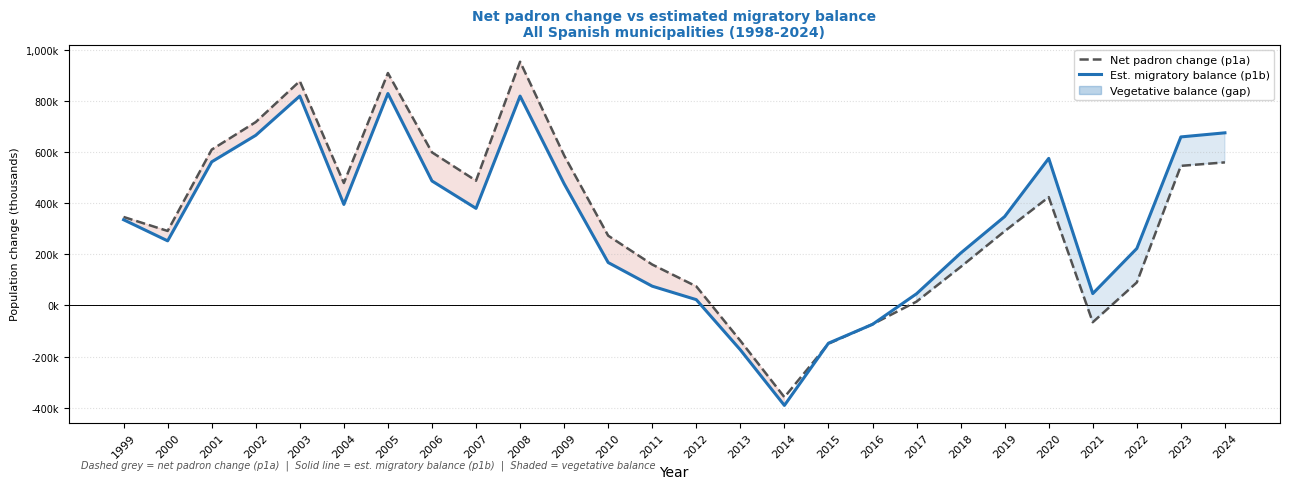

Saved -> p1c_fig1_national_en.png
Saved -> p1c_fig1_national_es.png


In [7]:
FIG1_LABELS = {
    'en': {
        'ylabel': 'Population change (thousands)',
        'xlabel': 'Year',
        'title' : 'Net padron change vs estimated migratory balance\nAll Spanish municipalities (1998-2024)',
        'note'  : 'Dashed grey = net padron change (p1a)  |  Solid line = est. migratory balance (p1b)  |  Shaded = vegetative balance',
    },
    'es': {
        'ylabel': 'Variacion de poblacion (miles)',
        'xlabel': 'Anno',
        'title' : 'Variacion neta padron vs saldo migratorio estimado\nMunicipios espannoles (1998-2024)',
        'note'  : 'Linea gris discontinua = variacion neta padron (p1a)  |  Linea continua = saldo migratorio estimado (p1b)  |  Area sombreada = crecimiento vegetativo',
    },
}

nat_merged = p1a_nat.merge(p1b_nat, on='Year', suffixes=('_p1a', '_p1b')).dropna()

for lang, labels in FIG1_LABELS.items():
    years = nat_merged['Year'].tolist()
    v_p1a = nat_merged['Net_change_p1a'].values
    v_p1b = nat_merged['Net_change_p1b'].values

    fig, ax = plt.subplots(figsize=(13, 5))
    draw_comparison_panel(ax, years, v_p1a, v_p1b, '#2171b5',
                          labels['title'], labels['ylabel'], lang)
    ax.set_xlabel(labels['xlabel'], fontsize=10)
    ax.set_xticks(years)
    ax.set_xticklabels(years, rotation=45, fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}k'))
    ax.legend(handles=make_legend_handles(lang), fontsize=8, loc='upper right')
    ax.text(0.01, -0.12, labels['note'], transform=ax.transAxes,
            fontsize=7, color='#555555', style='italic')
    plt.tight_layout()
    fp = FIGURES_DIR / f'p1c_fig1_national_{lang}.png'
    plt.savefig(fp, dpi=300, bbox_inches='tight')
    if lang == 'en': plt.show()
    else: plt.close()
    print(f'Saved -> {fp.name}')

---
## 4 · Figure 2 — By municipality size group

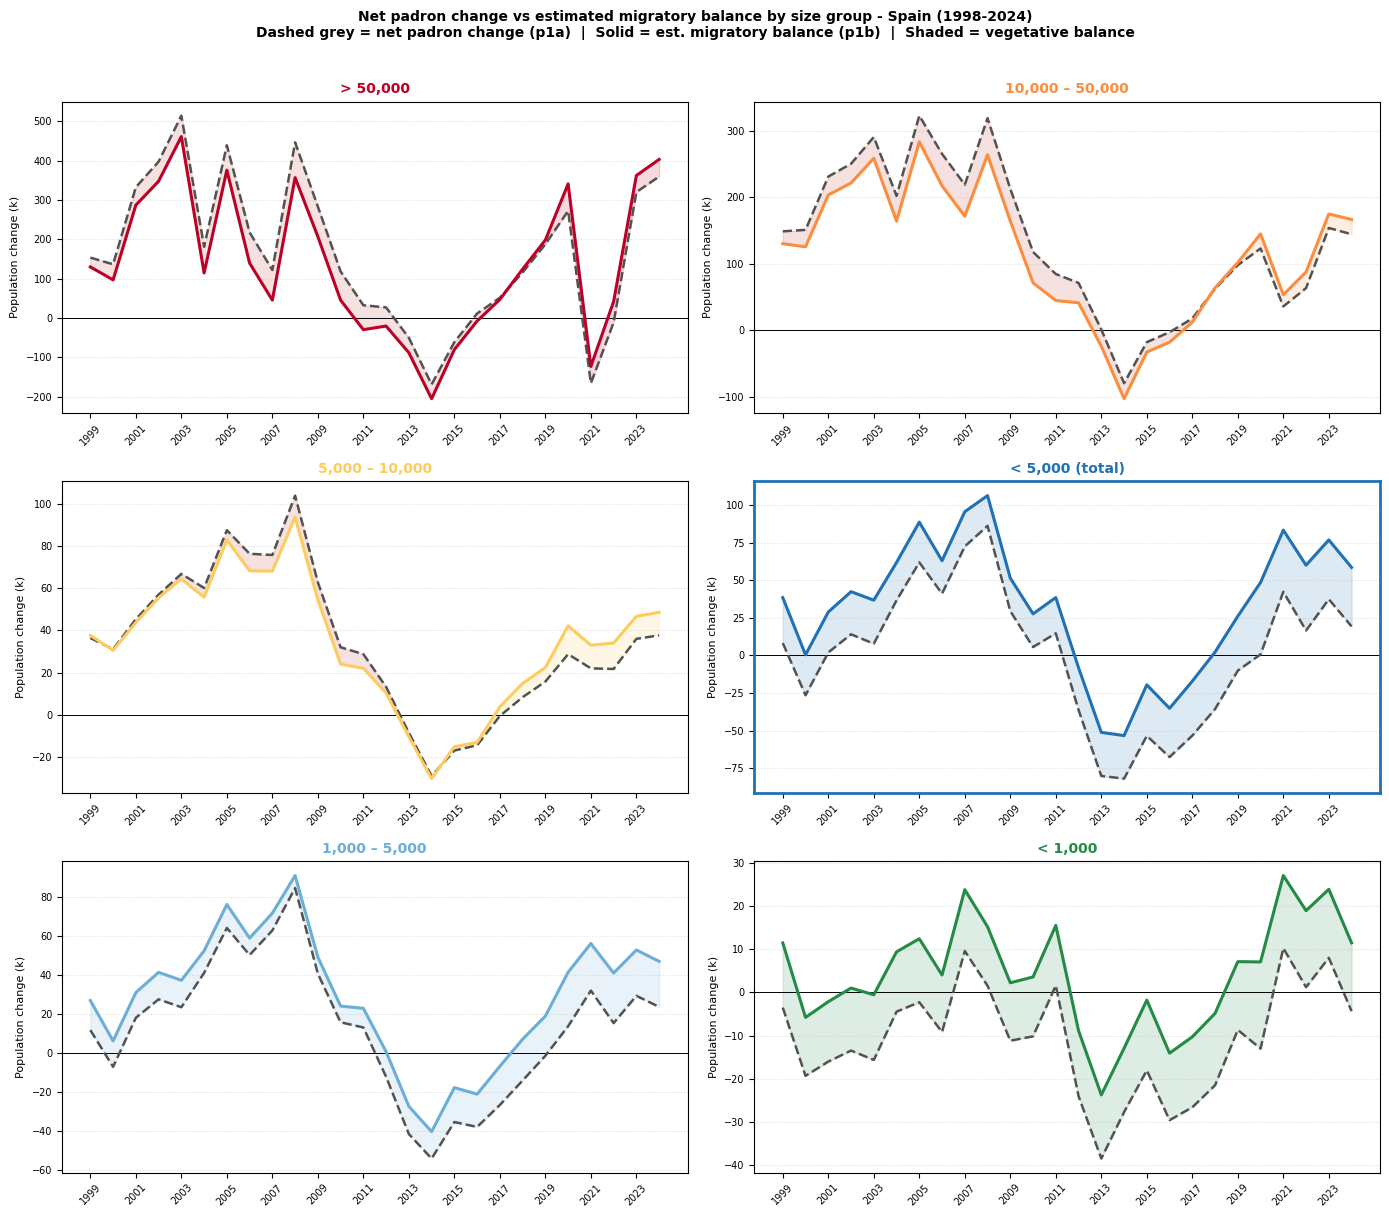

Saved -> p1c_fig2_size_combined_en.png
Saved -> p1c_fig2_size_pair_top_en.png
Saved -> p1c_fig2_size_pair_mid_en.png
Saved -> p1c_fig2_size_pair_bot_en.png
Saved -> p1c_fig2_size_individual_gt_50000_en.png
Saved -> p1c_fig2_size_individual_10000_–_50000_en.png
Saved -> p1c_fig2_size_individual_5000_–_10000_en.png
Saved -> p1c_fig2_size_individual_lt_5000_(total)_en.png
Saved -> p1c_fig2_size_individual_1000_–_5000_en.png
Saved -> p1c_fig2_size_individual_lt_1000_en.png
Saved -> p1c_fig2_size_combined_es.png
Saved -> p1c_fig2_size_pair_top_es.png
Saved -> p1c_fig2_size_pair_mid_es.png
Saved -> p1c_fig2_size_pair_bot_es.png
Saved -> p1c_fig2_size_individual_gt_50000_es.png
Saved -> p1c_fig2_size_individual_10000_–_50000_es.png
Saved -> p1c_fig2_size_individual_5000_–_10000_es.png
Saved -> p1c_fig2_size_individual_lt_5000_(total)_es.png
Saved -> p1c_fig2_size_individual_1000_–_5000_es.png
Saved -> p1c_fig2_size_individual_lt_1000_es.png

All Figure 2 variants saved.


In [8]:
SIZE_LABELS = {
    'en': {
        'ylabel'  : 'Population change (k)',
        'suptitle': 'Net padron change vs estimated migratory balance by size group - Spain (1998-2024)',
        'note'    : 'Dashed grey = net padron change (p1a)  |  Solid = est. migratory balance (p1b)  |  Shaded = vegetative balance',
    },
    'es': {
        'ylabel'  : 'Variacion (miles)',
        'suptitle': 'Variacion neta padron vs saldo migratorio estimado por grupo de tamano - Espanna (1998-2024)',
        'note'    : 'Linea gris discontinua = variacion neta padron (p1a)  |  Linea continua = saldo migratorio estimado (p1b)  |  Area sombreada = crecimiento vegetativo',
    },
}

SIZE_TITLES_EN = {
    '> 50,000'        : '> 50,000',
    '10,000 – 50,000' : '10,000 – 50,000',
    '5,000 – 10,000'  : '5,000 – 10,000',
    '< 5,000 (total)' : '< 5,000 (total)',
    '1,000 – 5,000'   : '1,000 – 5,000',
    '< 1,000'         : '< 1,000',
}

SIZE_TITLES_ES = {
    '> 50,000'        : '> 50.000',
    '10,000 – 50,000' : '10.000 – 50.000',
    '5,000 – 10,000'  : '5.000 – 10.000',
    '< 5,000 (total)' : '< 5.000 (total)',
    '1,000 – 5,000'   : '1.000 – 5.000',
    '< 1,000'         : '< 1.000',
}

def get_size_series(grp):
    a = p1a_size[p1a_size['size_group'] == grp].sort_values('Year')
    b = p1b_size[p1b_size['size_group'] == grp].sort_values('Year')
    m = a.merge(b, on='Year', suffixes=('_p1a', '_p1b')).dropna()
    return m['Year'].tolist(), m['Net_change_p1a'].values, m['Net_change_p1b'].values


def draw_size_comparison(ax, grp, lang, labels):
    years, v_p1a, v_p1b = get_size_series(grp)
    if not years:
        ax.set_visible(False)
        return
    color = SIZE_COLORS.get(grp, '#2171b5')
    title = SIZE_TITLES_ES[grp] if lang == 'es' else SIZE_TITLES_EN[grp]
    if grp == '< 5,000 (total)':
        for spine in ax.spines.values():
            spine.set_linewidth(2)
            spine.set_edgecolor(color)
    draw_comparison_panel(ax, years, v_p1a, v_p1b, color, title, labels['ylabel'], lang)


for lang, labels in SIZE_LABELS.items():
    show = (lang == 'en')

    fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=False)
    for i, grp in enumerate(SIZE_ORDER):
        draw_size_comparison(axes.flatten()[i], grp, lang, labels)
    fig.suptitle(f"{labels['suptitle']}\n{labels['note']}", fontsize=10, fontweight='bold', y=1.01)
    plt.tight_layout()
    fp = FIGURES_DIR / f'p1c_fig2_size_combined_{lang}.png'
    plt.savefig(fp, dpi=300, bbox_inches='tight')
    if show: plt.show()
    else: plt.close()
    print(f'Saved -> {fp.name}')

    for pair_idx, pair_name in enumerate(['top', 'mid', 'bot']):
        grp_a = SIZE_ORDER[pair_idx * 2]
        grp_b = SIZE_ORDER[pair_idx * 2 + 1]
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        draw_size_comparison(axes[0], grp_a, lang, labels)
        draw_size_comparison(axes[1], grp_b, lang, labels)
        fig.suptitle(f"{labels['suptitle']}\n{labels['note']}", fontsize=10, fontweight='bold', y=1.02)
        plt.tight_layout()
        fp = FIGURES_DIR / f'p1c_fig2_size_pair_{pair_name}_{lang}.png'
        plt.savefig(fp, dpi=300, bbox_inches='tight')
        plt.close()
        print(f'Saved -> {fp.name}')

    for grp in SIZE_ORDER:
        fig, ax = plt.subplots(figsize=(8, 5))
        draw_size_comparison(ax, grp, lang, labels)
        color = SIZE_COLORS.get(grp, '#2171b5')
        ax.legend(handles=make_legend_handles(lang, color), fontsize=8)
        fig.suptitle(f"{labels['suptitle']}\n{labels['note']}", fontsize=9, fontweight='bold', y=1.02)
        plt.tight_layout()
        slug = grp.replace(',', '').replace(' ', '_').replace('>', 'gt').replace('<', 'lt')
        fp = FIGURES_DIR / f'p1c_fig2_size_individual_{slug}_{lang}.png'
        plt.savefig(fp, dpi=300, bbox_inches='tight')
        plt.close()
        print(f'Saved -> {fp.name}')

print('\nAll Figure 2 variants saved.')

---
## 5 · Figure 3 — By Goerlich (2016) typology

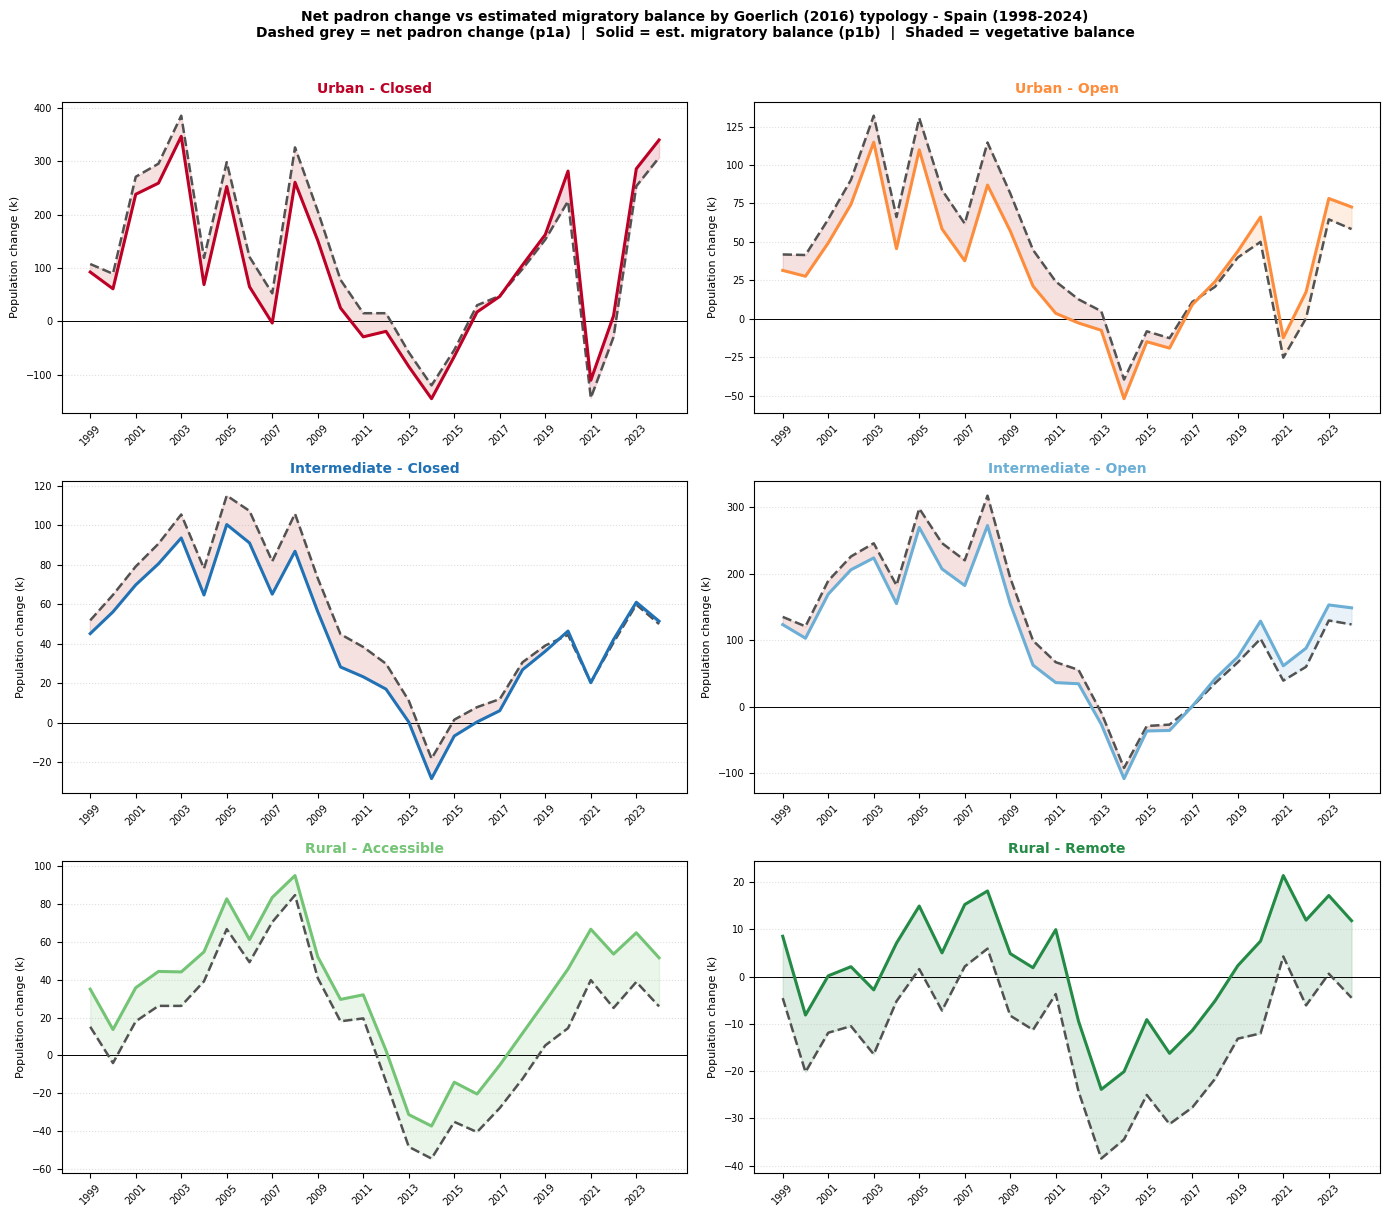

Saved -> p1c_fig3_typology_combined_en.png
Saved -> p1c_fig3_typology_pair_top_en.png
Saved -> p1c_fig3_typology_pair_mid_en.png
Saved -> p1c_fig3_typology_pair_bot_en.png
Saved -> p1c_fig3_typology_individual_Urbano_Cerrado_en.png
Saved -> p1c_fig3_typology_individual_Urbano_Abierto_en.png
Saved -> p1c_fig3_typology_individual_Intermedio_Cerrado_en.png
Saved -> p1c_fig3_typology_individual_Intermedio_Abierto_en.png
Saved -> p1c_fig3_typology_individual_Rural_Accesible_en.png
Saved -> p1c_fig3_typology_individual_Rural_Remoto_en.png
Saved -> p1c_fig3_typology_combined_es.png
Saved -> p1c_fig3_typology_pair_top_es.png
Saved -> p1c_fig3_typology_pair_mid_es.png
Saved -> p1c_fig3_typology_pair_bot_es.png
Saved -> p1c_fig3_typology_individual_Urbano_Cerrado_es.png
Saved -> p1c_fig3_typology_individual_Urbano_Abierto_es.png
Saved -> p1c_fig3_typology_individual_Intermedio_Cerrado_es.png
Saved -> p1c_fig3_typology_individual_Intermedio_Abierto_es.png
Saved -> p1c_fig3_typology_individual_Rur

In [9]:
TYPOLOGY_LABELS = {
    'en': {
        'ylabel'  : 'Population change (k)',
        'suptitle': 'Net padron change vs estimated migratory balance by Goerlich (2016) typology - Spain (1998-2024)',
        'note'    : 'Dashed grey = net padron change (p1a)  |  Solid = est. migratory balance (p1b)  |  Shaded = vegetative balance',
    },
    'es': {
        'ylabel'  : 'Variacion (miles)',
        'suptitle': 'Variacion neta padron vs saldo migratorio estimado por tipologia Goerlich (2016) - Espanna (1998-2024)',
        'note'    : 'Linea gris discontinua = variacion neta padron (p1a)  |  Linea continua = saldo migratorio estimado (p1b)  |  Area sombreada = crecimiento vegetativo',
    },
}

TYPOLOGY_TITLES_EN = {
    'Urbano - Cerrado': 'Urban - Closed', 'Urbano - Abierto': 'Urban - Open',
    'Intermedio - Cerrado': 'Intermediate - Closed', 'Intermedio - Abierto': 'Intermediate - Open',
    'Rural - Accesible': 'Rural - Accessible', 'Rural - Remoto': 'Rural - Remote',
}
TYPOLOGY_TITLES_ES = {
    'Urbano - Cerrado': 'Urbano - Cerrado', 'Urbano - Abierto': 'Urbano - Abierto',
    'Intermedio - Cerrado': 'Intermedio - Cerrado', 'Intermedio - Abierto': 'Intermedio - Abierto',
    'Rural - Accesible': 'Rural - Accesible', 'Rural - Remoto': 'Rural - Remoto',
}


def get_typ_series(typ):
    a = p1a_typ[p1a_typ['tipo_goerlich'] == typ].sort_values('Year')
    b = p1b_typ[p1b_typ['tipo_goerlich'] == typ].sort_values('Year')
    m = a.merge(b, on='Year', suffixes=('_p1a', '_p1b')).dropna()
    return m['Year'].tolist(), m['Net_change_p1a'].values, m['Net_change_p1b'].values


def draw_typ_comparison(ax, typ, lang, labels):
    years, v_p1a, v_p1b = get_typ_series(typ)
    if not years:
        ax.set_visible(False)
        return
    color = GOERLICH_COLORS[typ]
    title = TYPOLOGY_TITLES_EN[typ] if lang == 'en' else TYPOLOGY_TITLES_ES[typ]
    draw_comparison_panel(ax, years, v_p1a, v_p1b, color, title, labels['ylabel'], lang)


for lang, labels in TYPOLOGY_LABELS.items():
    show = (lang == 'en')

    fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=False)
    for i, typ in enumerate(TYPOLOGY_ORDER):
        draw_typ_comparison(axes.flatten()[i], typ, lang, labels)
    fig.suptitle(f"{labels['suptitle']}\n{labels['note']}", fontsize=10, fontweight='bold', y=1.01)
    plt.tight_layout()
    fp = FIGURES_DIR / f'p1c_fig3_typology_combined_{lang}.png'
    plt.savefig(fp, dpi=300, bbox_inches='tight')
    if show: plt.show()
    else: plt.close()
    print(f'Saved -> {fp.name}')

    for pair_idx, pair_name in enumerate(['top', 'mid', 'bot']):
        typ_a = TYPOLOGY_ORDER[pair_idx * 2]
        typ_b = TYPOLOGY_ORDER[pair_idx * 2 + 1]
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        draw_typ_comparison(axes[0], typ_a, lang, labels)
        draw_typ_comparison(axes[1], typ_b, lang, labels)
        fig.suptitle(f"{labels['suptitle']}\n{labels['note']}", fontsize=10, fontweight='bold', y=1.02)
        plt.tight_layout()
        fp = FIGURES_DIR / f'p1c_fig3_typology_pair_{pair_name}_{lang}.png'
        plt.savefig(fp, dpi=300, bbox_inches='tight')
        plt.close()
        print(f'Saved -> {fp.name}')

    for typ in TYPOLOGY_ORDER:
        fig, ax = plt.subplots(figsize=(8, 5))
        draw_typ_comparison(ax, typ, lang, labels)
        color = GOERLICH_COLORS[typ]
        ax.legend(handles=make_legend_handles(lang, color), fontsize=8)
        fig.suptitle(f"{labels['suptitle']}\n{labels['note']}", fontsize=9, fontweight='bold', y=1.02)
        plt.tight_layout()
        slug = typ.replace(' ', '_').replace('-', '').replace('__', '_')
        fp = FIGURES_DIR / f'p1c_fig3_typology_individual_{slug}_{lang}.png'
        plt.savefig(fp, dpi=300, bbox_inches='tight')
        plt.close()
        print(f'Saved -> {fp.name}')

print('\nAll Figure 3 variants saved.')

---
## 6 · Interpretation notes

*Fill in after running.*

**Key visual findings from p1c:**

1. The shaded area (vegetative balance) is **consistently negative** for rural
   typologies and small municipalities throughout the series, confirming the
   structural demographic deficit of these territories.
2. The **gap narrows post-2018** for Rural Accessible and <5,000 municipalities,
   meaning the migratory recovery partially compensates the vegetative deficit.
3. For **Urban typologies**, the shaded area changes sign in 2020-2021, reflecting
   the COVID urban exodus in the migratory balance while excess COVID mortality
   simultaneously reduces the padron change.
4. The **two lines converge** most clearly in Rural Remote post-2019, suggesting
   that the vegetative deficit is now being partially offset by in-migration
   for the first time in the series.

---
## 7 · Dependencies

All packages are standard and available in the `rural-migration` conda environment:

```
pandas, numpy, matplotlib
```

No additional installs required for this notebook.